**<FONT COLOR="blue">Maquina de soporte de vectores (SVM)</FONT>**

**INTRODUCCION**

Las Support Vector Machines o Máquinas de Soporte Vectorial son una serie de algoritmos de aprendizaje supervisado. Si bien originariamente se desarrollaron como un método de clasificación binaria, su aplicación se ha ido extendiendo a problemas de clasificación múltiple y regresión

**REGRESION VECTORIAL DE SOPORTE (SVR)**

Es muy común designarlas por el acrónimo SVR (del inglés Support Vector Regression).  Dado que la teoría de las SVM de Regresión se construyó a partir de modificaciones de la SVM de clasificación, Se apoyan en el mismo fundamento de las clásicas SVM de clasificación, pero en este caso el hiperplano busca ajustarse lo mejor posible a las muestras de entrenamiento.

Dataset: Teen Mental Health Dataset (1,200 observaciones)
Objetivo: Predecir el nivel de estrés a partir de variables de uso de redes sociales, sueño,
rendimiento académico y salud mental.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['savefig.bbox'] = "tight"
plt.style.use('ggplot')


In [3]:
datos = pd.read_excel("datosestresyansiedad.xlsx")
datos.head(3)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,anxiety_level,addiction_level,depression_label,stress_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,1,0,2
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,1,10,0,8
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,4,2,0,2


In [4]:
print("Shape original:", datos.shape)


Shape original: (1200, 13)


La base de datos contiene 13 variables y 1200 observaciones, entre ellas definimos a la variable stress_level como la variable dependiente y a las demas como independientes. Las variables categóricas (gender, platform_usage, social_interaction_level) serán codificadas numéricamente con LabelEncoder.


In [5]:
# Codificacion de variables categoricas
le = LabelEncoder()
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    datos[col] = le.fit_transform(datos[col])


In [6]:
# Normalizar nombres de columnas
datos.columns = [c.strip().lower() for c in datos.columns]
print("Shape limpio :", datos.shape)
print("Columnas     :", list(datos.columns))
print()
print(datos.head(3))


Shape limpio : (1200, 13)
Columnas     : ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'anxiety_level', 'addiction_level', 'depression_label', 'stress_level']

   age  gender  daily_social_media_hours  platform_usage  sleep_hours  \
0   14       1                       7.9               1          7.4   
1   19       0                       1.9               2          8.0   
2   17       0                       1.3               1          7.6   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   

   social_interaction_level  anxiety_level  addiction_level  depression_label  \
0                         1              2 

In [7]:
# resumen de las variables
print(datos.describe().round(2))


           age   gender  daily_social_media_hours  platform_usage  \
count  1200.00  1200.00                   1200.00         1200.00   
mean     15.93     0.51                      4.54            1.01   
std       2.02     0.50                      2.03            0.81   
min      13.00     0.00                      1.00            0.00   
25%      14.00     0.00                      2.80            0.00   
50%      16.00     1.00                      4.50            1.00   
75%      18.00     1.00                      6.30            2.00   
max      19.00     1.00                      8.00            2.00   

       sleep_hours  screen_time_before_sleep  academic_performance  \
count      1200.00                   1200.00               1200.00   
mean          6.45                      1.74                  2.99   
std           1.44                      0.72                  0.58   
min           4.00                      0.50                  2.00   
25%           5.20          

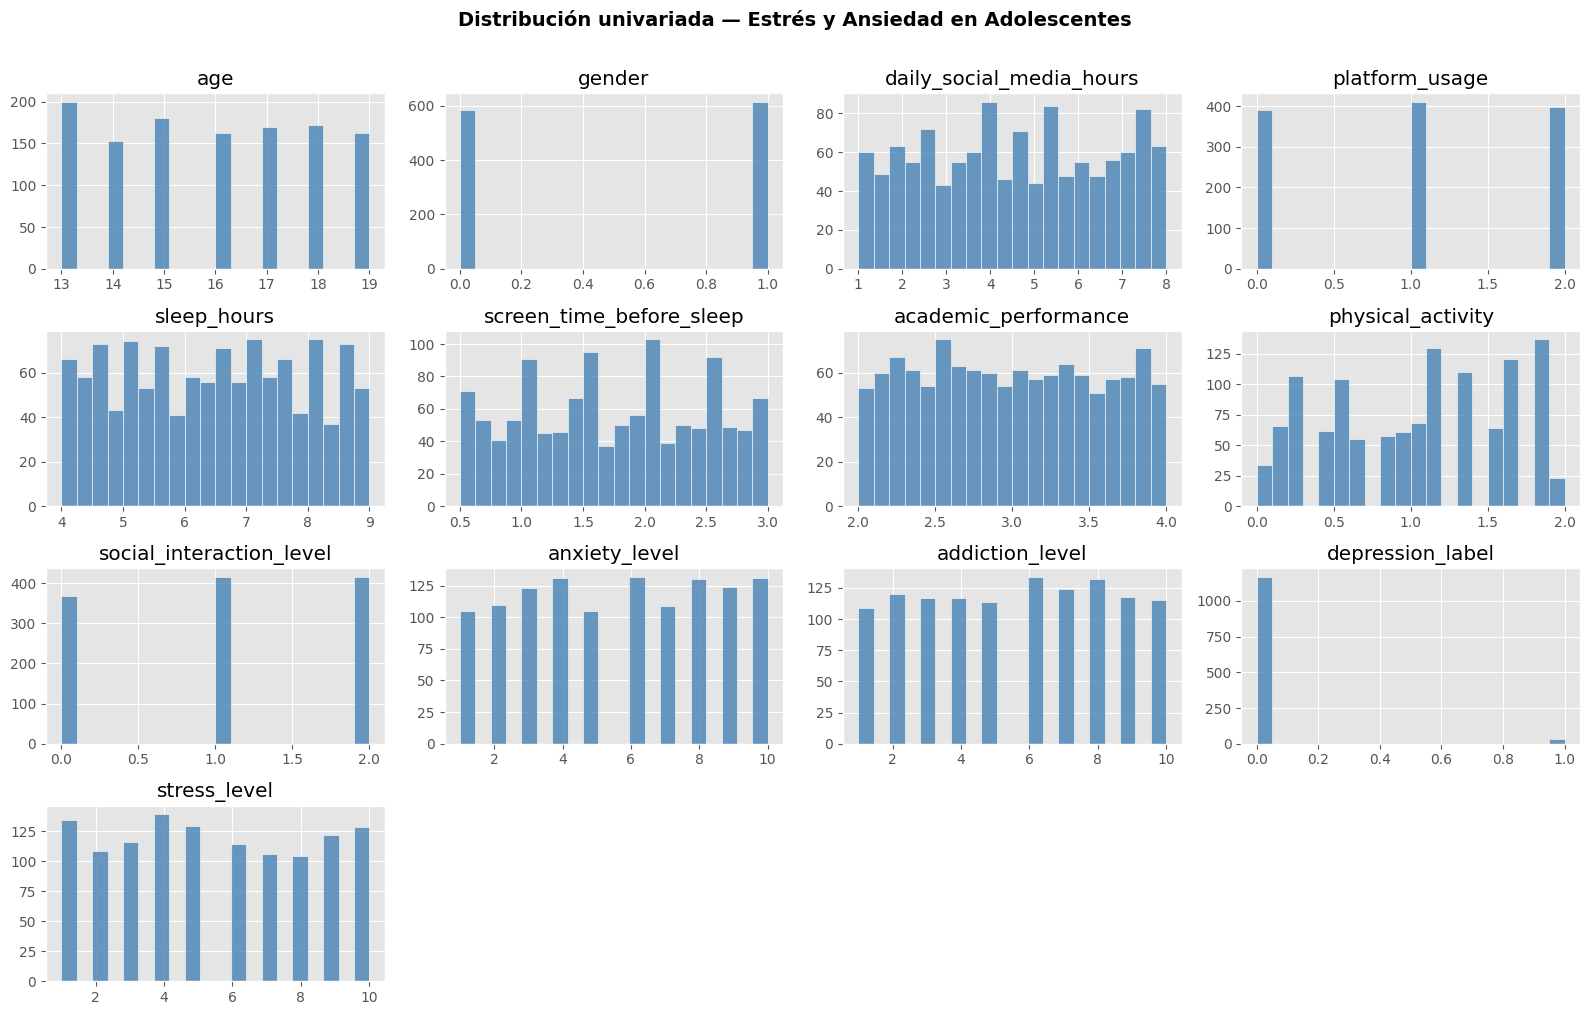

In [8]:
# [2] HISTOGRAMAS UNIVARIADOS
fig = plt.figure(figsize=(16, 10))
ax  = fig.gca()
datos.hist(ax=ax, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
fig.suptitle("Distribución univariada — Estrés y Ansiedad en Adolescentes",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


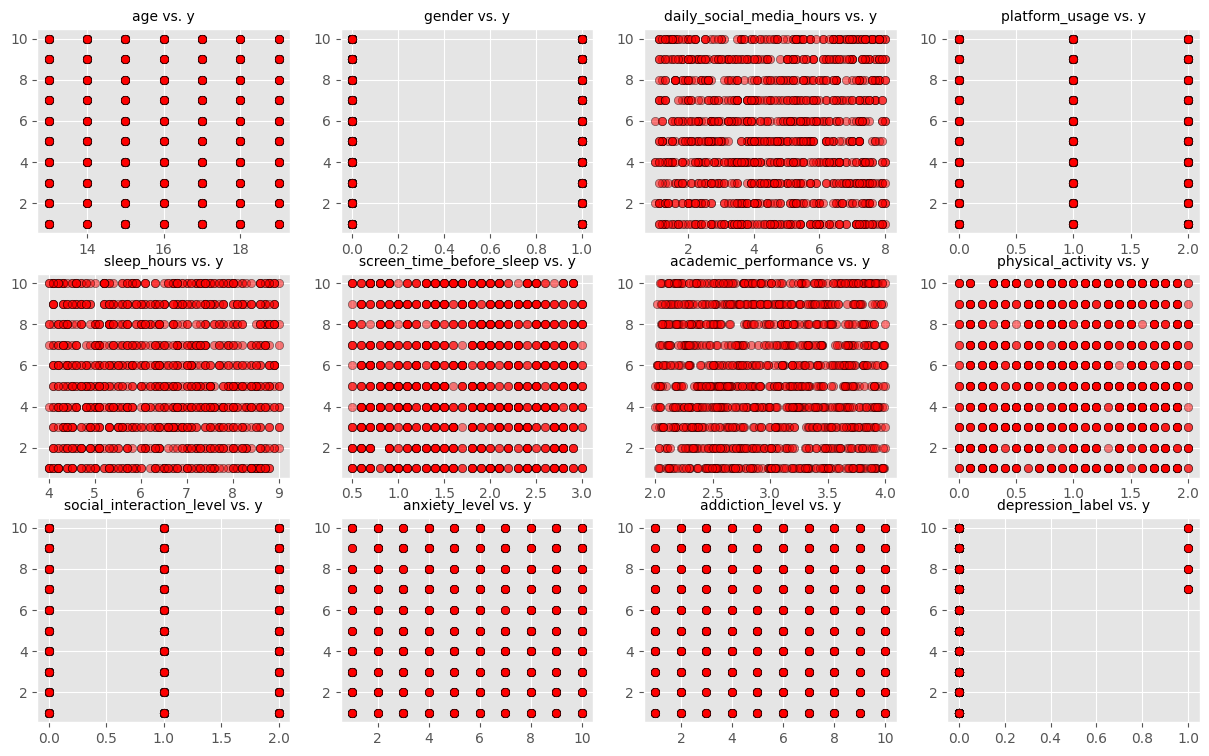

In [9]:
# Gráfico de dispersión
independent_vars_list = [c for c in datos.columns if c != 'stress_level']
n_vars = len(independent_vars_list)
n_cols_plot = 4
n_rows_plot = (n_vars + n_cols_plot - 1) // n_cols_plot

fig, ax = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, n_rows_plot * 3))
ax = ax.ravel()
for i, col in enumerate(independent_vars_list):
    ax[i].scatter(datos[col], datos['stress_level'], edgecolor='k', color='red', alpha=0.50)
    ax[i].set_title(f"{col} vs. y", fontsize=10)
    ax[i].grid(True)
for j in range(n_vars, len(ax)):
    fig.delaxes(ax[j])
plt.show()


Se muestra el grafico de dispersión de los datos de las variables explicativas frente a la variable dependiente

### Box Plots for Independent Variables

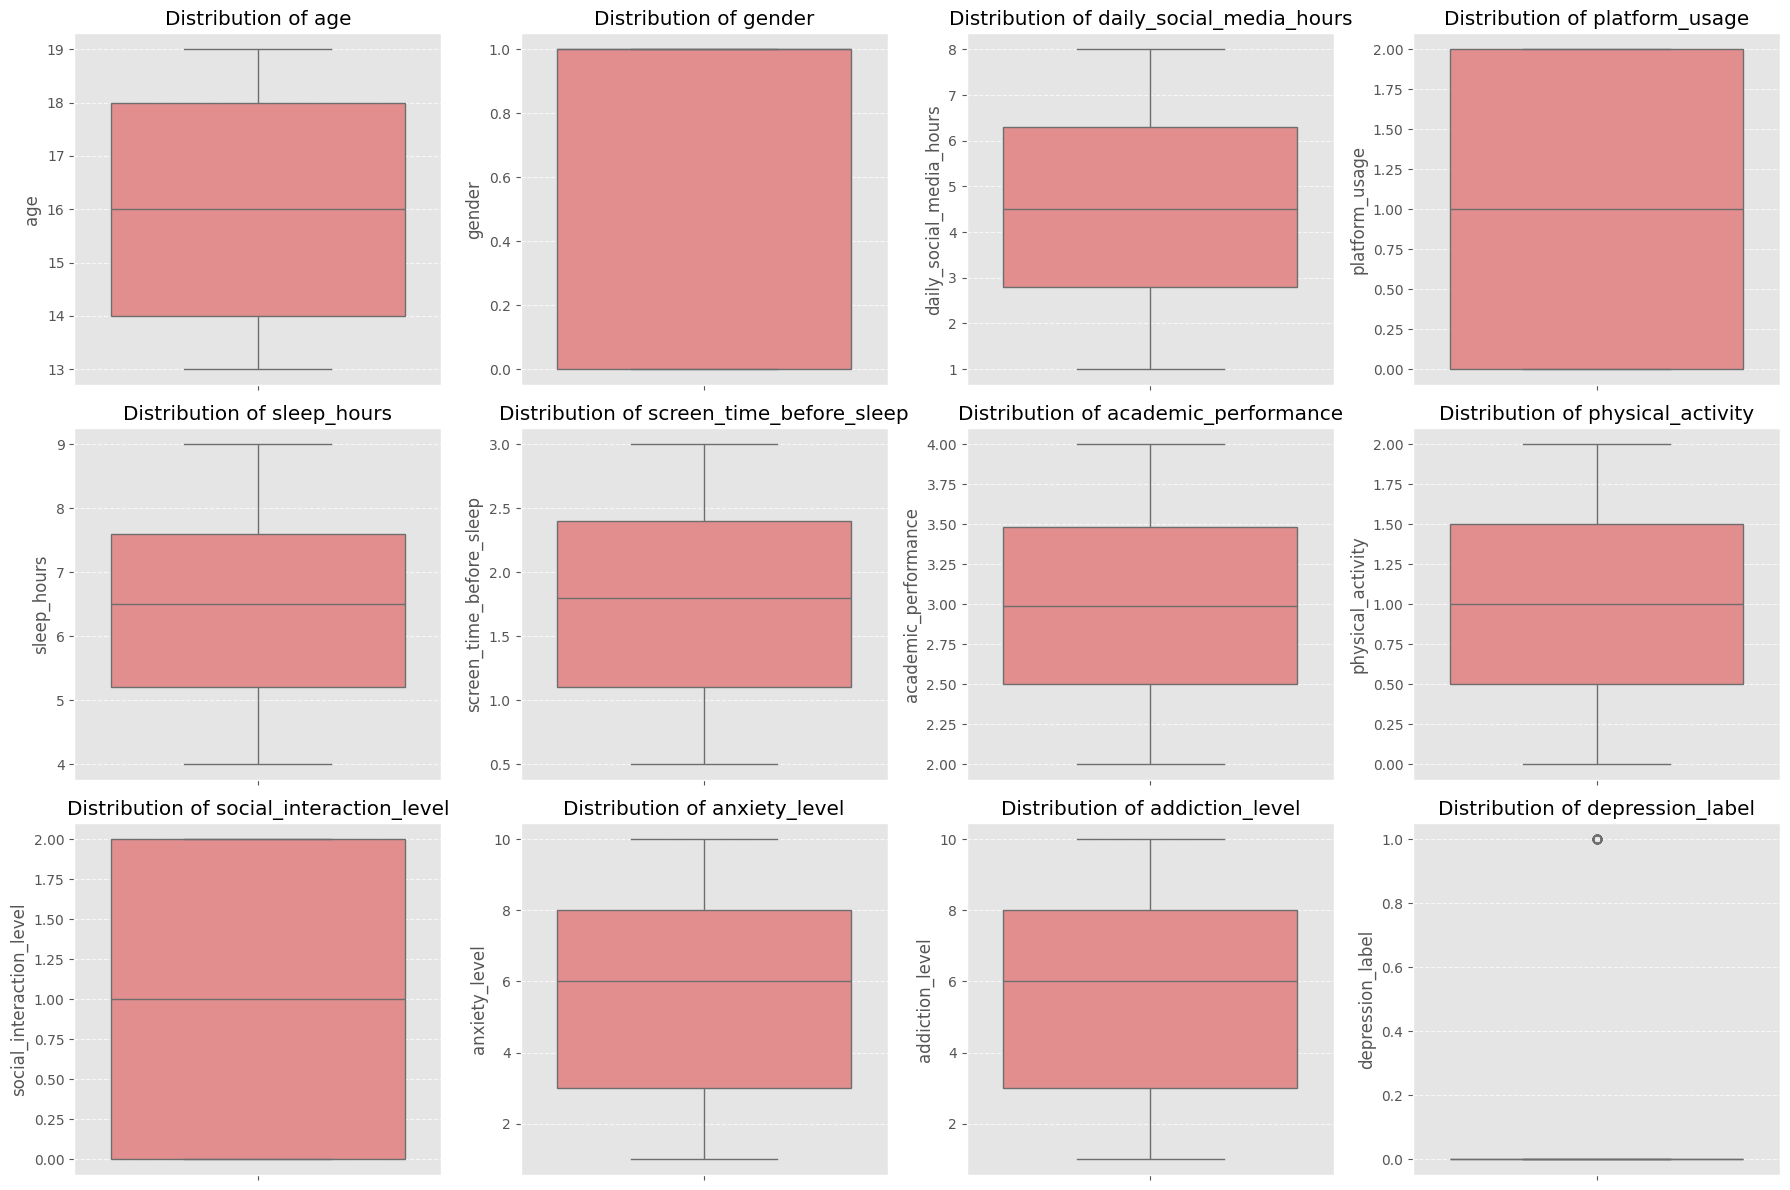

In [10]:
independent_vars = datos.columns.drop('stress_level')
n_independent_vars = len(independent_vars)

n_cols = 4 # Number of columns for the subplots
n_rows = (n_independent_vars + n_cols - 1) // n_cols # Calculate rows dynamically (ceiling division)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4)) # Adjust figsize height dynamically
axes = axes.flatten()

for i, col in enumerate(independent_vars):
    sns.boxplot(y=datos[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(n_independent_vars, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Correlation Matrix

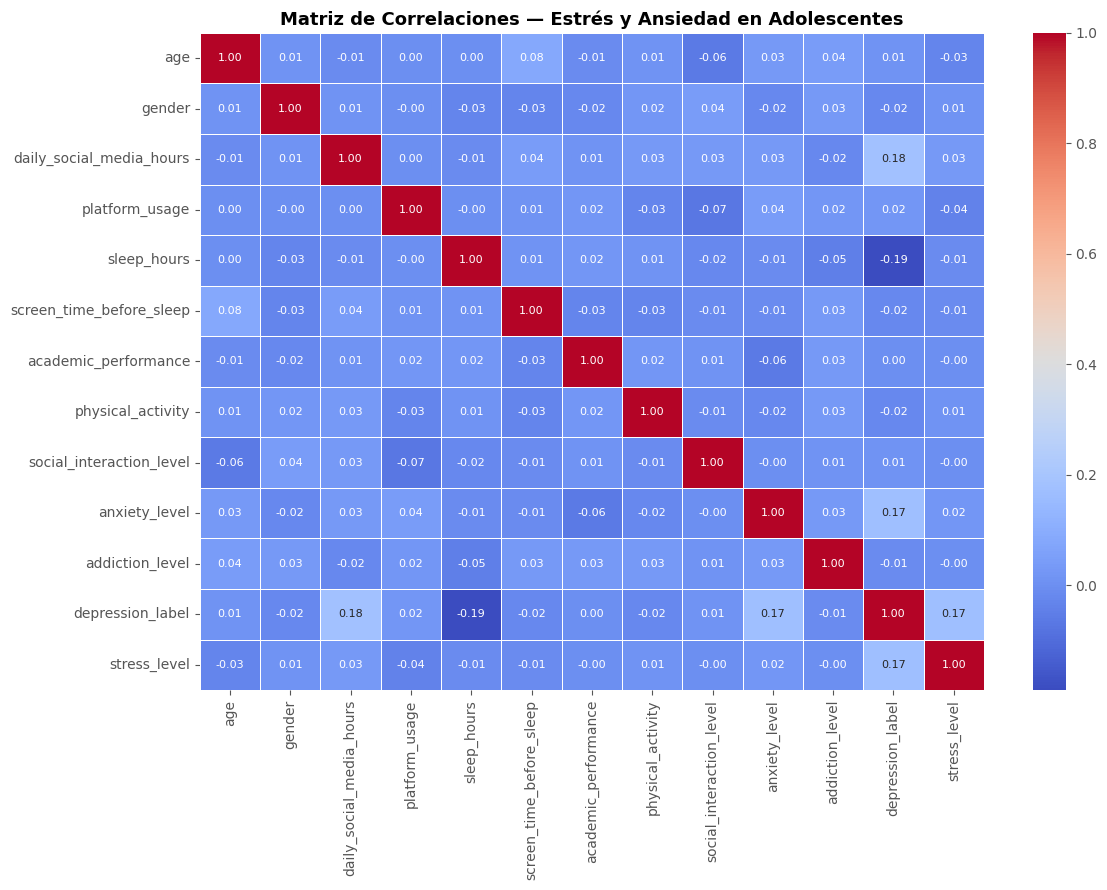

In [11]:
#  [5] MAPA DE CALOR DE CORRELACIONES
plt.figure(figsize=(12, 9))
sns.heatmap(
    datos.corr().round(2),
    annot      = True,
    cmap       = 'coolwarm',
    fmt        = ".2f",
    linewidths = 0.5,
    annot_kws  = {"size": 8}
    )
plt.title("Matriz de Correlaciones — Estrés y Ansiedad en Adolescentes",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# definimos la variable dependiente
X = datos.drop(columns = 'stress_level')
Y = datos['stress_level']

# separamos la data en train y test
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        Y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )
print(f"Train: {X_train.shape} | Test: {X_test.shape}\n")


Train: (960, 12) | Test: (240, 12)



In [13]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
from sklearn.svm import SVR


**MODELO SVR con kernel lineal**

In [15]:
# [8] BÚSQUEDA DEL MEJOR C (kernel linear)
print(f"{'C':>4}  {'RMSE':>8}  {'MSE':>10}  {'R2':>7}")
print("─" * 36)

_c_values  = []
_rmse_list = []
_best_c    = 1
_best_rmse = float('inf')

for _c in range(1, 50, 2):
  _svm_tmp  = SVR(kernel='linear', C=_c)
  _svm_tmp.fit(X_train, y_train)
  _pred_tmp = _svm_tmp.predict(X_test)

  _mse_tmp  = mean_squared_error(y_test, _pred_tmp)
  _rmse_tmp = np.sqrt(_mse_tmp)
  _r2_tmp   = r2_score(y_test, _pred_tmp)

  _c_values.append(_c)
  _rmse_list.append(_rmse_tmp)

  # Actualizar mejor C
  if _rmse_tmp < _best_rmse:
    _best_rmse = _rmse_tmp
    _best_c    = _c

  print(f"{_c:>4}  {_rmse_tmp:>8.4f}  {_mse_tmp:>10.4f}  {_r2_tmp:>7.4f}")

print(f"\n  ✔ Mejor C encontrado : {_best_c}  (RMSE: {_best_rmse:.4f})\n")


   C      RMSE         MSE       R2
────────────────────────────────────
   1    2.8700      8.2371   0.0065
   3    2.8701      8.2373   0.0065
   5    2.8701      8.2373   0.0065
   7    2.8702      8.2379   0.0064
   9    2.8698      8.2359   0.0067
  11    2.8700      8.2369   0.0065
  13    2.8701      8.2373   0.0065
  15    2.8701      8.2375   0.0065
  17    2.8701      8.2375   0.0065
  19    2.8701      8.2373   0.0065
  21    2.8701      8.2373   0.0065
  23    2.8701      8.2374   0.0065
  25    2.8698      8.2360   0.0066
  27    2.8701      8.2374   0.0065
  29    2.8700      8.2371   0.0065
  31    2.8701      8.2376   0.0064
  33    2.8701      8.2372   0.0065
  35    2.8698      8.2357   0.0067
  37    2.8698      8.2360   0.0066
  39    2.8701      8.2374   0.0065
  41    2.8698      8.2359   0.0066
  43    2.8701      8.2372   0.0065
  45    2.8698      8.2359   0.0066
  47    2.8698      8.2355   0.0067
  49    2.8701      8.2373   0.0065

  ✔ Mejor C encontrado : 4

Para encontrar el mejor modelo con kernel lineal, se consideró diferentes valores para la constante C, de manera que se obtiene el valor más bajo de la raiz del error cuadrático medio.

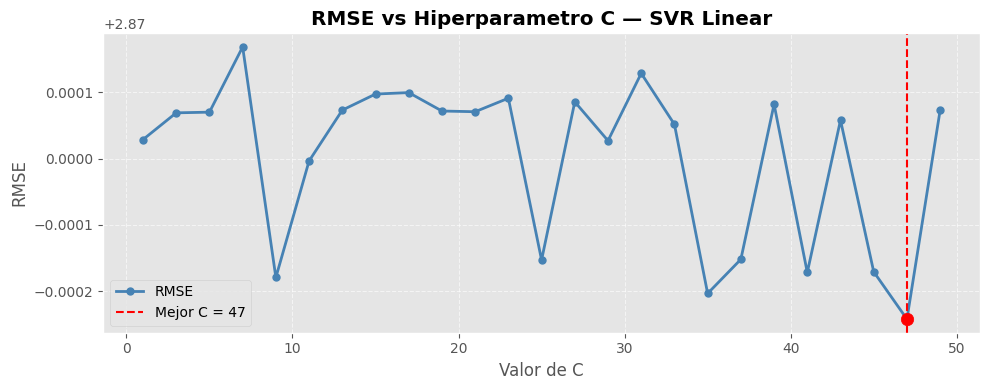

In [16]:
# [9] CURVA RMSE vs C
plt.figure(figsize=(10, 4))
plt.plot(_c_values, _rmse_list, marker='o', color='steelblue',
  linewidth=2, markersize=5, label='RMSE')
plt.axvline(_best_c, color='red', linestyle='--',
  label=f'Mejor C = {_best_c}')
plt.scatter([_best_c], [_best_rmse], color='red', zorder=5, s=80)
plt.xlabel("Valor de C")
plt.ylabel("RMSE")
plt.title("RMSE vs Hiperparametro C — SVR Linear", fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [17]:
# Entrenamiento del Modelo final
svmlinear = SVR(kernel='linear', C=_best_c)
svmlinear.fit(X_train, y_train)

print(f"Modelo entrenado: SVR(kernel='linear', C={_best_c})\n")


Modelo entrenado: SVR(kernel='linear', C=47)



In [18]:
# Prediccion
svmlinearpred = svmlinear.predict(X = X_test)


In [19]:
# Error cuadrático medio (MSE)
_mse_final  = mean_squared_error(y_test, svmlinearpred)
_rmse_final = np.sqrt(_mse_final)
_mae_final  = np.mean(np.abs(y_test - svmlinearpred))
_r2_final   = r2_score(y_test, svmlinearpred)
print("─" * 40)
print("  Metricas Finales — SVR Linear")
print("─" * 40)
print(f"  MAE  : {_mae_final:.4f}")
print(f"  MSE  : {_mse_final:.4f}")
print(f"  RMSE : {_rmse_final:.4f}")
print(f"  R²   : {_r2_final:.4f}")
print("─" * 40)


────────────────────────────────────────
  Metricas Finales — SVR Linear
────────────────────────────────────────
  MAE  : 2.4442
  MSE  : 8.2355
  RMSE : 2.8698
  R²   : 0.0067
────────────────────────────────────────


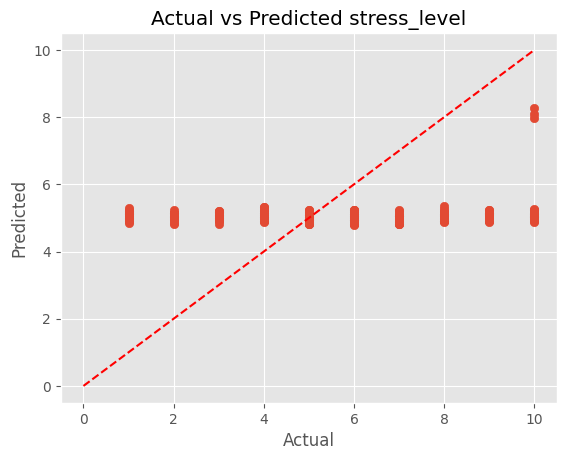

In [20]:
plt.scatter(y_test, svmlinearpred)
plt.plot([0, y_test.max()], [0, y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted stress_level")
plt.show()


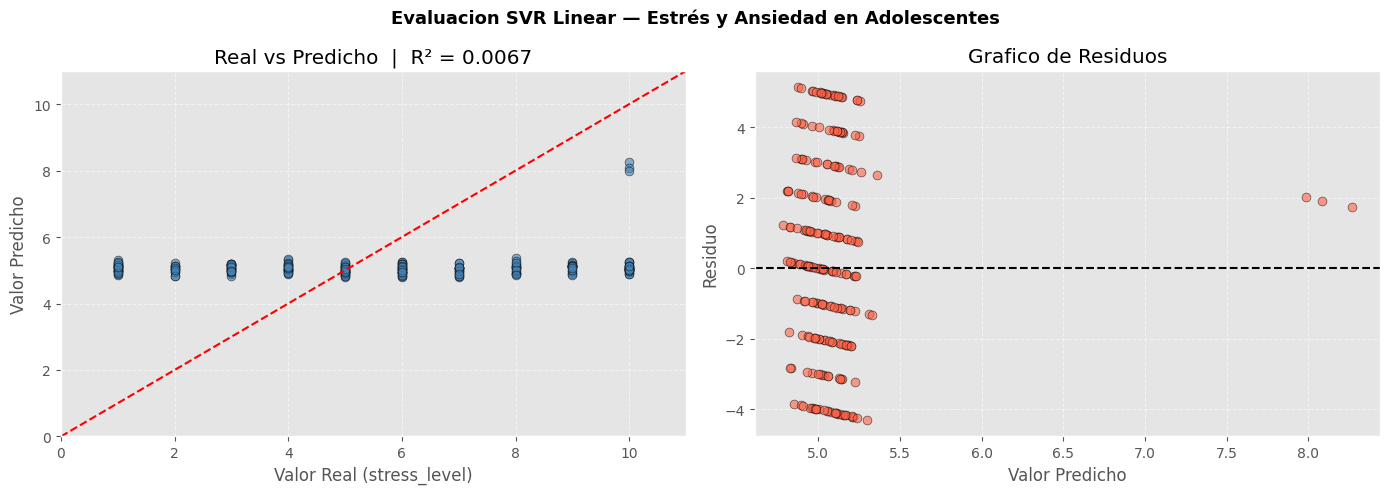

In [21]:
# ══════════════════════════════════════════════#  [12] GRÁFICO: REAL vs PREDICHO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 12.1 Scatter: Real vs Predicho ──
axes[0].scatter(y_test.flatten(), svmlinearpred,
  color='steelblue', edgecolor='k', alpha=0.6, s=40)
_lim = [min(y_test.min(), svmlinearpred.min()) - 1,
  max(y_test.max(), svmlinearpred.max()) + 1]
axes[0].plot(_lim, _lim, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlim(_lim)
axes[0].set_ylim(_lim)
axes[0].set_xlabel("Valor Real (stress_level)")
axes[0].set_ylabel("Valor Predicho")
axes[0].set_title(f"Real vs Predicho  |  R² = {_r2_final:.4f}")
axes[0].grid(True, linestyle='--', alpha=0.5)

# ── 12.2 Residuos ──
_residuos = y_test.flatten() - svmlinearpred
axes[1].scatter(svmlinearpred, _residuos,
  color='tomato', edgecolor='k', alpha=0.6, s=40)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Valor Predicho")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Grafico de Residuos")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Evaluacion SVR Linear — Estrés y Ansiedad en Adolescentes",
  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [22]:
# Ejemplo de nuevos datos para predecir (asegúrate de que tenga las mismas columnas que X_train)
# Puedes modificar este DataFrame con tus propios valores
# gender: 0=female, 1=male | platform_usage: 0=Both, 1=Instagram, 2=TikTok
# social_interaction_level: 0=high, 1=low, 2=medium
new_data = pd.DataFrame({
    'age':                        [15,   17,   19],
    'gender':                     [1,    0,    1],
    'daily_social_media_hours':   [7.0,  2.0,  4.5],
    'platform_usage':             [2,    1,    0],
    'sleep_hours':                [5.0,  8.0,  6.5],
    'screen_time_before_sleep':   [3.0,  0.5,  2.0],
    'academic_performance':       [2.5,  3.8,  3.0],
    'physical_activity':          [0.3,  1.5,  0.8],
    'social_interaction_level':   [1,    2,    0],
    'anxiety_level':              [8,    2,    5],
    'addiction_level':            [9,    1,    5],
    'depression_label':           [0,    0,    0],
})

# Obtener las columnas que se usaron para entrenar el modelo
feature_columns = X.columns.tolist()

# Asegurarse de que new_data tenga las mismas columnas y en el mismo orden que X_train
new_data_aligned = new_data[feature_columns]

# Escalar los nuevos datos
new_data_scaled = scaler.transform(new_data_aligned);

# Realizar predicciones con svmlinear
new_predictions = svmlinear.predict(new_data_scaled)

print("Predicciones para los nuevos datos:")
for i, pred in enumerate(new_predictions):
    print(f"Nueva observación {i+1}: {pred:.2f}")


Predicciones para los nuevos datos:
Nueva observación 1: 5.09
Nueva observación 2: 5.03
Nueva observación 3: 5.17


**MODELO SVR con kernel polinomial**

In [23]:
from sklearn.metrics import mean_squared_error, make_scorer
#probando valores de C
print ('C', 'RMSE', 'MSE')
for i in np.arange (0.001, 0.1, 0.002):
  svmpoly = SVR(kernel = 'poly', C=i, gamma="auto", degree=2)
  svmpoly.fit(X_train, y_train)
  svmpolypred = svmpoly.predict(X = X_test)
  # Calculate Mean Squared Error (MSE) first
  calculated_mse = mean_squared_error(
      y_true  = y_test,
      y_pred  = svmpolypred
      )
  # Then calculate Root Mean Squared Error (RMSE)
  rmse = np.sqrt(calculated_mse)
  mse = calculated_mse
  print(i, f"  {rmse:.4f}", f"  {mse:.4f}" )


C RMSE MSE
0.001   2.8979   8.3981
0.003   2.8873   8.3363
0.005   2.8777   8.2813
0.007   2.8704   8.2391
0.009000000000000001   2.8678   8.2245
0.011   2.8664   8.2162
0.013000000000000001   2.8651   8.2090
0.015   2.8632   8.1980
0.017   2.8622   8.1923
0.019000000000000003   2.8613   8.1871
0.021   2.8603   8.1813
0.023   2.8591   8.1743
0.025   2.8577   8.1663
0.027000000000000003   2.8566   8.1604
0.029   2.8556   8.1542
0.031   2.8546   8.1490
0.033   2.8539   8.1448
0.035   2.8534   8.1418
0.037000000000000005   2.8529   8.1391
0.039   2.8524   8.1363
0.041   2.8518   8.1328
0.043000000000000003   2.8511   8.1289
0.045   2.8505   8.1254
0.047   2.8499   8.1219
0.049   2.8491   8.1175
0.051000000000000004   2.8483   8.1127
0.053000000000000005   2.8475   8.1081
0.055   2.8468   8.1041
0.057   2.8460   8.0996
0.059000000000000004   2.8452   8.0951
0.061   2.8443   8.0899
0.063   2.8433   8.0846
0.065   2.8425   8.0798
0.067   2.8416   8.0749
0.069   2.8408   8.0701
0.071000000000

Para encontrar el mejor modelo con kernel polinomial, se consideró diferentes valores para la constante C, de manera que se obtiene el valor más bajo del error cuadrático medio.

In [24]:
# Modelo
svmpoly = SVR(kernel="poly", C=0.013, gamma=0.1, degree=2)
svmpoly.fit(X_train, y_train)


SVR(C=0.013, degree=2, gamma=0.1, kernel='poly')

In [25]:
# Prediccion
svmpolypred = svmpoly.predict(X = X_test)
datapredict = pd.DataFrame(y_test, columns=['Actual']) # Initialize datapredict DataFrame with actual values
datapredict["svmpolypred"]=svmpolypred
datapredict


,Actual,svmpolypred
0,10,5.066049
1,7,5.114318
2,3,5.015911
3,1,5.123736
4,8,5.061432
...,...,...
235,5,5.108405
236,5,5.096592
237,5,5.125614
238,6,5.149156


In [26]:
import numpy as np
# Error de raíz cuadrada media (RMSE)
mse = mean_squared_error(
        y_true  = y_test,
        y_pred  = svmpolypred
)
rmse = np.sqrt(mse)
print(f"El error (rmse) de test es: {rmse}")


El error (rmse) de test es: 2.8614998369048474


In [27]:
# Error cuadrático medio (MSE)
mse = rmse*rmse
print(f"El error (mse) de test es: {mse}")


El error (mse) de test es: 8.18818131660647


In [28]:
# Ejemplo de nuevos datos para predecir (asegúrate de que tenga las mismas columnas que X_train)
# Puedes modificar este DataFrame con tus propios valores
new_data = pd.DataFrame({
    'age':                        [15,   17,   19],
    'gender':                     [1,    0,    1],
    'daily_social_media_hours':   [7.0,  2.0,  4.5],
    'platform_usage':             [2,    1,    0],
    'sleep_hours':                [5.0,  8.0,  6.5],
    'screen_time_before_sleep':   [3.0,  0.5,  2.0],
    'academic_performance':       [2.5,  3.8,  3.0],
    'physical_activity':          [0.3,  1.5,  0.8],
    'social_interaction_level':   [1,    2,    0],
    'anxiety_level':              [8,    2,    5],
    'addiction_level':            [9,    1,    5],
    'depression_label':           [0,    0,    0],
})

# Obtener las columnas que se usaron para entrenar el modelo
feature_columns = X.columns.tolist()

# Asegurarse de que new_data tenga las mismas columnas y en el mismo orden que X_train
new_data_aligned = new_data[feature_columns]

# Escalar los nuevos datos
new_data_scaled = scaler.transform(new_data_aligned);

# Realizar predicciones con svmpoly
new_predictions = svmpoly.predict(new_data_scaled)

print("Predicciones para los nuevos datos:")
for i, pred in enumerate(new_predictions):
    print(f"Nueva observación {i+1}: {pred:.2f}")


Predicciones para los nuevos datos:
Nueva observación 1: 5.11
Nueva observación 2: 5.10
Nueva observación 3: 5.09


**MODELO SVR con kernel gaussiano**

In [29]:
#probando valores de C
print ('C','RMSE','MSE')
for i in range (2, 15,1):
  svmrbf = SVR(kernel = 'rbf',C=i, gamma=1, epsilon=1)
  svmrbf.fit(X_train, y_train)
  svmrbfpred = svmrbf.predict(X = X_test)
  calculated_mse = mean_squared_error(
      y_true  = y_test,
      y_pred   = svmrbfpred
      )
  rmse = np.sqrt(calculated_mse)
  mse = calculated_mse
  print(f"{i:.4f}", f"  {rmse:.4f}", f"  {mse:.4f}" )


C RMSE MSE
2.0000   2.8841   8.3179
3.0000   2.8855   8.3262
4.0000   2.8853   8.3251
5.0000   2.8853   8.3249
6.0000   2.8853   8.3249
7.0000   2.8853   8.3249
8.0000   2.8853   8.3249
9.0000   2.8853   8.3249
10.0000   2.8853   8.3249
11.0000   2.8853   8.3249
12.0000   2.8853   8.3249
13.0000   2.8853   8.3249
14.0000   2.8853   8.3249


In [30]:
#probando valores de Gamma

print ('Gamma','    RMSE','    MSE')

for i in np.arange (0.0001, 0.01, 0.0002):
  svmrbf = SVR(kernel = 'rbf',C=10, gamma=i, epsilon=1)
  svmrbf.fit(X_train, y_train)

  svmrbfpred = svmrbf.predict(X = X_test)
  calculated_mse = mean_squared_error(
          y_true  = y_test,
          y_pred  = svmrbfpred
        )
  rmse = np.sqrt(calculated_mse)
  mse = calculated_mse
  print(f"{i:.4f}", f"  {rmse:.4f}", f"  {mse:.4f}" )


Gamma     RMSE     MSE
0.0001   2.8934   8.3717
0.0003   2.8775   8.2801
0.0005   2.8726   8.2516
0.0007   2.8722   8.2493
0.0009   2.8716   8.2462
0.0011   2.8710   8.2425
0.0013   2.8702   8.2378
0.0015   2.8693   8.2326
0.0017   2.8682   8.2268
0.0019   2.8671   8.2205
0.0021   2.8659   8.2133
0.0023   2.8646   8.2059
0.0025   2.8632   8.1981
0.0027   2.8617   8.1895
0.0029   2.8602   8.1806
0.0031   2.8585   8.1713
0.0033   2.8569   8.1620
0.0035   2.8552   8.1521
0.0037   2.8535   8.1423
0.0039   2.8517   8.1322
0.0041   2.8499   8.1220
0.0043   2.8481   8.1118
0.0045   2.8463   8.1013
0.0047   2.8445   8.0913
0.0049   2.8428   8.0813
0.0051   2.8410   8.0712
0.0053   2.8393   8.0614
0.0055   2.8376   8.0519
0.0057   2.8359   8.0425
0.0059   2.8344   8.0338
0.0061   2.8328   8.0250
0.0063   2.8316   8.0177
0.0065   2.8304   8.0110
0.0067   2.8293   8.0050
0.0069   2.8285   8.0004
0.0071   2.8278   7.9965
0.0073   2.8272   7.9928
0.0075   2.8263   7.9879
0.0077   2.8255   7.9836
0.

In [31]:
#probando valores de Epsilon

print ('Epsilon','    RMSE','    MSE')

for i in np.arange (0.00001, 0.65, 0.01):
  svmrbf = SVR(kernel = 'rbf',C=10, gamma=0.0019, epsilon=i)
  svmrbf.fit(X_train, y_train)

  svmrbfpred = svmrbf.predict(X = X_test)
  calculated_mse = mean_squared_error(
          y_true  = y_test,
          y_pred  = svmrbfpred
        )
  rmse = np.sqrt(calculated_mse)
  mse = calculated_mse
  print(f"{i:.4f}", f"  {rmse:.4f}", f"  {mse:.4f}" )


Epsilon     RMSE     MSE
0.0000   2.8684   8.2280
0.0100   2.8675   8.2228
0.0200   2.8673   8.2212
0.0300   2.8674   8.2222
0.0400   2.8664   8.2161
0.0500   2.8666   8.2176
0.0600   2.8669   8.2191
0.0700   2.8666   8.2173
0.0800   2.8663   8.2156
0.0900   2.8658   8.2128
0.1000   2.8658   8.2125
0.1100   2.8654   8.2104
0.1200   2.8653   8.2097
0.1300   2.8652   8.2095
0.1400   2.8656   8.2115
0.1500   2.8661   8.2144
0.1600   2.8664   8.2160
0.1700   2.8668   8.2183
0.1800   2.8672   8.2206
0.1900   2.8673   8.2216
0.2000   2.8677   8.2239
0.2100   2.8682   8.2264
0.2200   2.8687   8.2294
0.2300   2.8689   8.2304
0.2400   2.8690   8.2312
0.2500   2.8692   8.2323
0.2600   2.8691   8.2320
0.2700   2.8696   8.2347
0.2800   2.8702   8.2381
0.2900   2.8701   8.2377
0.3000   2.8704   8.2389
0.3100   2.8707   8.2408
0.3200   2.8714   8.2447
0.3300   2.8718   8.2473
0.3400   2.8714   8.2447
0.3500   2.8712   8.2436
0.3600   2.8707   8.2408
0.3700   2.8692   8.2323
0.3800   2.8690   8.2309


In [32]:
#Modelo
svmrbf = SVR(kernel = 'rbf',C=10, gamma=0.0019, epsilon=0.4)
svmrbf.fit(X_train, y_train)


SVR(C=10, epsilon=0.4, gamma=0.0019)

In [33]:
y_pred = svmrbf.predict(X_test) # ojo ver escalado


In [34]:
# Predicción
svmrbfpred = svmrbf.predict(X = X_test)
datapredict["svmrbfpred"]=svmrbfpred
datapredict


,Actual,svmpolypred,svmrbfpred
0,10,5.066049,5.423693
1,7,5.114318,5.250395
2,3,5.015911,4.771945
3,1,5.123736,5.389490
4,8,5.061432,4.762482
...,...,...,...
235,5,5.108405,4.979516
236,5,5.096592,4.875454
237,5,5.125614,5.226808
238,6,5.149156,4.950266


In [35]:
# Error cuadrático medio (MSE)
mse = mean_squared_error(
        y_true  = y_test,
        y_pred  = svmrbfpred
       )
print(f"El error (mse) de test es: {mse}")

# Error de raíz cuadrada media (RMSE)
rmse = np.sqrt(mse)
print(f"El error (rmse) de test es: {rmse}")


El error (mse) de test es: 8.229926816915983
El error (rmse) de test es: 2.8687849025181347


**MODELO SVR con kernel sigmoidal**

In [36]:
#probando valores de C

print ('C','    RMSE','    MSE')

for i in range (1, 15,1):
  svmsigmoid = SVR(kernel = 'sigmoid',C=i, gamma=1)
  svmsigmoid.fit(X_train, y_train)

  svmsigmoidpred = svmsigmoid.predict(X = X_test)

  # Calculate Mean Squared Error (MSE) first
  mse = mean_squared_error(
          y_true  = y_test,
          y_pred  = svmsigmoidpred
        )
  # Then calculate Root Mean Squared Error (RMSE)
  rmse = np.sqrt(mse)
  print(f"{i:.0f}", f"  {rmse:.4f}", f"  {mse:.4f}" )


C     RMSE     MSE
1   24.1471   583.0834
2   49.0107   2402.0450
3   75.0994   5639.9137
4   93.2228   8690.4899
5   116.1129   13482.1976
6   146.1825   21369.3371
7   169.4962   28728.9783
8   181.1366   32810.4824
9   226.3081   51215.3588
10   250.1822   62591.1306
11   265.1965   70329.2055
12   285.2455   81364.9699
13   326.9787   106915.0736
14   355.8315   126616.0801


In [37]:
# Modelo
svmsigmoid = SVR(kernel = 'sigmoid',C=5, gamma=1)
svmsigmoid.fit(X_train, y_train)
SVR(C=5, gamma=1, kernel='sigmoid')


SVR(C=5, gamma=1, kernel='sigmoid')

In [38]:
# Predicción
svmsigmoidpred = svmsigmoid.predict(X = X_test)
datapredict["svmsigmoidpred"]=svmsigmoidpred
datapredict


,Actual,svmpolypred,svmrbfpred,svmsigmoidpred
0,10,5.066049,5.423693,-201.129762
1,7,5.114318,5.250395,94.901473
2,3,5.015911,4.771945,-98.231737
3,1,5.123736,5.389490,-41.684128
4,8,5.061432,4.762482,118.955391
...,...,...,...,...
235,5,5.108405,4.979516,75.856505
236,5,5.096592,4.875454,87.177285
237,5,5.125614,5.226808,31.507598
238,6,5.149156,4.950266,-31.282052


In [39]:
# Error cuadrático medio (MSE)
mse = mean_squared_error(
        y_true  = y_test,
        y_pred  = svmsigmoidpred
       )
print(f"El error (mse) de test es: {mse}")

# Error de raíz cuadrada media (RMSE)
rmse = np.sqrt(mse)
print(f"El error (rmse) de test es: {rmse}")


El error (mse) de test es: 13482.197578125702
El error (rmse) de test es: 116.1128656873376


### Mejor Modelo SVR (Kernel Gaussiano)

In [40]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error

# Create a copy of 'datos' to ensure consistent preprocessing
datos_for_model = datos.copy()

# Re-define X and Y from the processed 'datos_for_model'
X = datos_for_model.drop(columns = 'stress_level')
Y = datos_for_model['stress_level']

# Re-split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        Y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

# Re-Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize datapredict with actual values. This will ensure 'y_test' is available for subsequent cells.
datapredict = pd.DataFrame(y_test, columns=['Actual'])

# Modelo SVR con los mejores parámetros encontrados para el kernel RBF
best_svmrbf = SVR(kernel='rbf', C=10, gamma=0.0099, epsilon=1)
best_svmrbf.fit(X_train, y_train)

# Predicciones con el mejor modelo
best_svmrbf_pred = best_svmrbf.predict(X_test)

# Añadir las predicciones del mejor modelo al DataFrame datapredict
datapredict['best_svmrbf_pred'] = best_svmrbf_pred
display(datapredict.head())


,Actual,best_svmrbf_pred
0,10,5.797450
1,7,5.813277
2,3,4.685935
3,1,5.432903
4,8,4.915401


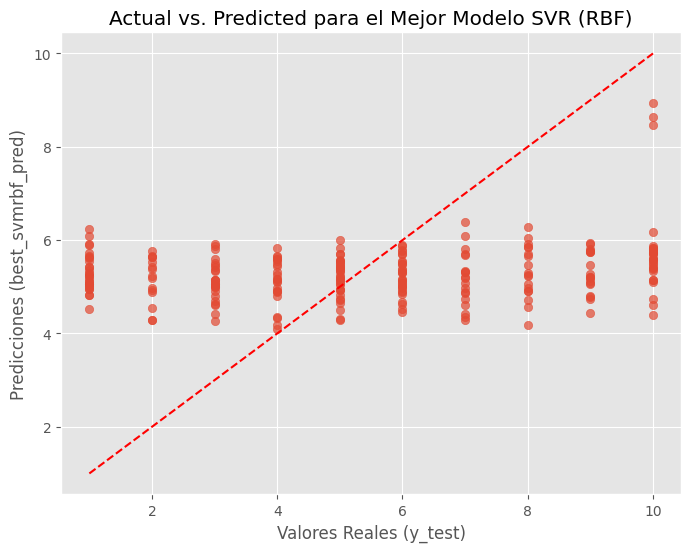

In [41]:
# Visualización de Actual vs. Predicted para el mejor modelo RBF
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_svmrbf_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (best_svmrbf_pred)')
plt.title('Actual vs. Predicted para el Mejor Modelo SVR (RBF)')
plt.grid(True)
plt.show()


### Predicción de Nuevos Valores

In [42]:
# Ejemplo de nuevos datos para predecir (asegúrate de que tenga las mismas columnas que X_train)
# Puedes modificar este DataFrame con tus propios valores
# gender: 0=female, 1=male | platform_usage: 0=Both, 1=Instagram, 2=TikTok
# social_interaction_level: 0=high, 1=low, 2=medium
new_data = pd.DataFrame({
    'age':                        [15,   17,   19],
    'gender':                     [1,    0,    1],
    'daily_social_media_hours':   [7.0,  2.0,  4.5],
    'platform_usage':             [2,    1,    0],
    'sleep_hours':                [5.0,  8.0,  6.5],
    'screen_time_before_sleep':   [3.0,  0.5,  2.0],
    'academic_performance':       [2.5,  3.8,  3.0],
    'physical_activity':          [0.3,  1.5,  0.8],
    'social_interaction_level':   [1,    2,    0],
    'anxiety_level':              [8,    2,    5],
    'addiction_level':            [9,    1,    5],
    'depression_label':           [0,    0,    0],
})

# Obtener las columnas que se usaron para entrenar el modelo (these are the columns of X)
feature_columns = X.columns.tolist() # Use X.columns instead of datos.drop(columns='stress_level').columns

# Asegurarse de que new_data tenga las mismas columnas y en el mismo orden que X_train
new_data_aligned = new_data[feature_columns]

# Escalar los nuevos datos
new_data_scaled = scaler.transform(new_data_aligned)

# Realizar predicciones con el modelo best_svmrbf
new_predictions = best_svmrbf.predict(new_data_scaled)

print("Predicciones para los nuevos datos:")
for i, pred in enumerate(new_predictions):
    print(f"Nueva observación {i+1}: {pred:.2f}")


Predicciones para los nuevos datos:
Nueva observación 1: 5.45
Nueva observación 2: 5.00
Nueva observación 3: 5.72


In [43]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, best_svmrbf_pred)
print(f"Mean Absolute Error (MAE) for the best SVR model (RBF) is: {mae:.4f}")

# Calculate R-squared score for the best SVR model (already calculated, but good to display with others)
r2 = r2_score(y_test, best_svmrbf_pred)
print(f"R-squared (R2) for the best SVR model (RBF) is: {r2:.4f}")


Mean Absolute Error (MAE) for the best SVR model (RBF) is: 2.3549
R-squared (R2) for the best SVR model (RBF) is: 0.0438
